Import Required Libraries

In [43]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [44]:
# Load dataset

data = pd.read_csv("spam.csv", encoding="latin-1")

data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Explore Dataset

In [45]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [46]:
# Check class distribution

data['v1'].value_counts()

,count
v1,
ham,4825
spam,747


Data Cleaning

In [47]:
# Keep only required columns

data = data[['v1','v2']]

data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [48]:
# Encode labels

data.loc[:, 'v1'] = data['v1'].map({
    'ham':0,
    'spam':1
})

data.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Split Dataset into Training and Testing Data

In [49]:
X = data['v2']
y = data['v1'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Text Feature Extraction Using TF-IDF

In [50]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)


X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)

Train Machine Learning Model

In [51]:
model = MultinomialNB()

model.fit(
    X_train_vectorized,
    y_train
)

MultinomialNB()

Make Predictions

In [52]:
y_pred = model.predict(
    X_test_vectorized
)

y_pred

array([0, 0, 0, ..., 0, 0, 1])

Model Evaluation

Accuracy

In [53]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9668161434977578


Precision, Recall, and F1 Score

In [54]:
print(
    "Precision:",
    precision_score(y_test,y_pred)
)

print(
    "Recall:",
    recall_score(y_test,y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test,y_pred)
)

Precision: 1.0
Recall: 0.7533333333333333
F1 Score: 0.8593155893536122


Classification Report

In [55]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



Confusion Matrix Visualization

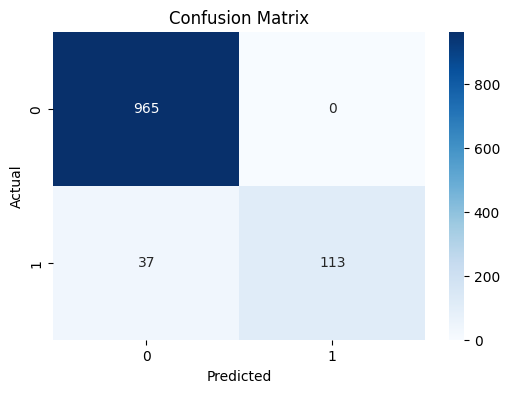

In [56]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Test Model With New Emails

In [57]:
def predict_email(email):

    email_vector = vectorizer.transform([email])

    prediction = model.predict(email_vector)

    if prediction[0] == 1:
        return "Spam Email"
    else:
        return "Not Spam"


predict_email(
    "Congratulations! You won a free lottery prize. Click here now."
)

'Spam Email'

In [58]:
print("""
The spam detection model was successfully implemented using
Scikit-Learn.

Steps performed:
1. Data preprocessing
2. Text feature extraction using TF-IDF
3. Model training using Multinomial Naive Bayes
4. Prediction on test data
5. Evaluation using accuracy, precision, recall, F1-score,
   and confusion matrix.

The model can classify incoming emails as spam or legitimate
messages with high accuracy.
""")


The spam detection model was successfully implemented using
Scikit-Learn.

Steps performed:
1. Data preprocessing
2. Text feature extraction using TF-IDF
3. Model training using Multinomial Naive Bayes
4. Prediction on test data
5. Evaluation using accuracy, precision, recall, F1-score,
   and confusion matrix.

The model can classify incoming emails as spam or legitimate
messages with high accuracy.

